# 한국 드라마 편수·러닝타임 감소 추이 분석
### 2000년대~현재 한국 드라마 포맷 변화를 통해 시청자 호흡이 짧아지고 있음을 증명합니다.
### 출처: 나무위키, 방송사 공식 자료, 한국콘텐츠진흥원 보고서 기반 수동 수집 데이터

In [1]:
pip install pandas plotly sqlalchemy pymysql python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 0. 환경 설정 및 라이브러리 로드

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pymysql
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

MYSQL_HOST = os.getenv('MYSQL_HOST', 'localhost')
MYSQL_USER = os.getenv('MYSQL_USER', 'root')
MYSQL_PW   = os.getenv('MYSQL_PASSWORD', '')
MYSQL_DB   = os.getenv('MYSQL_DB', 'youtube_data')

print(f'MySQL: {MYSQL_USER}@{MYSQL_HOST}/{MYSQL_DB}')

MySQL: root@localhost/youtube_data


## 1. YouTube API 클라이언트 초기화

In [4]:
def create_db_engine(host: str, user: str, pw: str, db: str):
    try:
        conn = pymysql.connect(host=host, user=user, password=pw, charset='utf8mb4')
        with conn.cursor() as cur:
            cur.execute(
                f'CREATE DATABASE IF NOT EXISTS `{db}` '
                f'CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci'
            )
        conn.close()

        url = f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4'
        engine = create_engine(url)
        with engine.connect() as c:
            c.execute(text('SELECT 1'))
        print(f'MySQL 연결 성공: {user}@{host}/{db}')
        return engine
    except Exception as e:
        print(f'[ERROR] MySQL 연결 실패: {e}')
        raise

engine = create_db_engine(MYSQL_HOST, MYSQL_USER, MYSQL_PW, MYSQL_DB)


MySQL 연결 성공: root@localhost/youtube_data


## 2. MySQL DB 연결

In [4]:
def create_db_engine(host: str, user: str, pw: str, db: str):
    try:
        conn = pymysql.connect(host=host, user=user, password=pw, charset='utf8mb4')
        with conn.cursor() as cur:
            cur.execute(
                f'CREATE DATABASE IF NOT EXISTS `{db}` '
                f'CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci'
            )
        conn.close()
 
        url    = f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4'
        engine = create_engine(url)
        with engine.connect() as c:
            c.execute(text('SELECT 1'))
        print(f'MySQL 연결 성공: {user}@{host}/{db}')
        return engine
    except Exception as e:
        print(f'[ERROR] MySQL 연결 실패: {e}')
        raise
 
engine = create_db_engine(MYSQL_HOST, MYSQL_USER, MYSQL_PW, MYSQL_DB)

MySQL 연결 성공: root@localhost/youtube_data


## 3. 데이터 정의 (수동 수집)

In [5]:
RAW_DATA = [
    # 2000년대 초 — 미니시리즈 정착 이전, 장편 드라마 전성기
    {'year': 2000, 'title': '허준',             'broadcaster': 'MBC', 'episodes': 64,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2001, 'title': '명성황후',          'broadcaster': 'KBS', 'episodes': 124, 'runtime_min': 60, 'era': '2000년대'},
    {'year': 2002, 'title': '겨울연가',          'broadcaster': 'KBS', 'episodes': 20,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2003, 'title': '대장금',            'broadcaster': 'MBC', 'episodes': 54,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2004, 'title': '파리의 연인',       'broadcaster': 'SBS', 'episodes': 20,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2005, 'title': '내 이름은 김삼순', 'broadcaster': 'MBC', 'episodes': 16,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2006, 'title': '주몽',             'broadcaster': 'MBC', 'episodes': 81,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2007, 'title': '이산',             'broadcaster': 'MBC', 'episodes': 77,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2008, 'title': '베토벤 바이러스', 'broadcaster': 'MBC', 'episodes': 18,  'runtime_min': 60, 'era': '2000년대'},
    {'year': 2009, 'title': '선덕여왕',         'broadcaster': 'MBC', 'episodes': 62,  'runtime_min': 60, 'era': '2000년대'},

    # 2010년대 — 케이블·종편 등장, 16부작 미니시리즈 표준화
    {'year': 2010, 'title': '추노',             'broadcaster': 'KBS', 'episodes': 24,  'runtime_min': 60, 'era': '2010년대'},
    {'year': 2011, 'title': '드림하이',         'broadcaster': 'KBS', 'episodes': 16,  'runtime_min': 60, 'era': '2010년대'},
    {'year': 2012, 'title': '신사의 품격',      'broadcaster': 'MBC', 'episodes': 20,  'runtime_min': 60, 'era': '2010년대'},
    {'year': 2013, 'title': '별에서 온 그대', 'broadcaster': 'MBC', 'episodes': 21,  'runtime_min': 60, 'era': '2010년대'},
    {'year': 2014, 'title': '미생',             'broadcaster': 'tvN', 'episodes': 20,  'runtime_min': 55, 'era': '2010년대'},
    {'year': 2015, 'title': '응답하라 1988', 'broadcaster': 'tvN', 'episodes': 20,  'runtime_min': 90, 'era': '2010년대'},
    {'year': 2016, 'title': '도깨비',           'broadcaster': 'tvN', 'episodes': 16,  'runtime_min': 75, 'era': '2010년대'},
    {'year': 2017, 'title': '슈츠',             'broadcaster': 'KBS', 'episodes': 16,  'runtime_min': 60, 'era': '2010년대'},
    {'year': 2018, 'title': '미스터 션샤인', 'broadcaster': 'tvN', 'episodes': 24,  'runtime_min': 70, 'era': '2010년대'},
    {'year': 2019, 'title': '호텔 델루나',      'broadcaster': 'tvN', 'episodes': 16,  'runtime_min': 65, 'era': '2010년대'},

    # 2020년대 — OTT·숏폼 영향, 편수·러닝타임 축소 본격화
    {'year': 2020, 'title': '사이코지만 괜찮아', 'broadcaster': 'tvN',     'episodes': 16, 'runtime_min': 60, 'era': '2020년대'},
    {'year': 2021, 'title': '갯마을 차차차',     'broadcaster': 'tvN',     'episodes': 16, 'runtime_min': 65, 'era': '2020년대'},
    {'year': 2022, 'title': '이상한 변호사 우영우', 'broadcaster': 'ENA',  'episodes': 16, 'runtime_min': 65, 'era': '2020년대'},
    {'year': 2023, 'title': '연인',             'broadcaster': 'MBC',      'episodes': 14, 'runtime_min': 60, 'era': '2020년대'},
    {'year': 2023, 'title': '무빙',             'broadcaster': '디즈니+',  'episodes': 20, 'runtime_min': 50, 'era': '2020년대'},
    {'year': 2024, 'title': '눈물의 여왕',      'broadcaster': 'tvN',      'episodes': 16, 'runtime_min': 65, 'era': '2020년대'},
    {'year': 2024, 'title': '졸업',             'broadcaster': 'MBC',      'episodes': 10, 'runtime_min': 50, 'era': '2020년대'},
    {'year': 2024, 'title': '정년이',           'broadcaster': 'KBS',      'episodes': 12, 'runtime_min': 55, 'era': '2020년대'},
    {'year': 2025, 'title': '폭싹 속았수다',    'broadcaster': 'Netflix',  'episodes': 8,  'runtime_min': 45, 'era': '2020년대'},
    {'year': 2025, 'title': '중증외상센터',     'broadcaster': 'Disney+',  'episodes': 12, 'runtime_min': 50, 'era': '2020년대'},
]

print(f'수집된 드라마 수: {len(RAW_DATA)}개')



수집된 드라마 수: 30개


## 4. DataFrame 정리

In [6]:
def build_dataframe(raw: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(raw)

    num_cols = ['year', 'episodes', 'runtime_min']
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    str_cols = ['title', 'broadcaster', 'era']
    for col in str_cols:
        df[col] = df[col].fillna('')

    df = df.sort_values('year').reset_index(drop=True)

    print('DataFrame 생성 완료')
    print(df.dtypes)
    return df

df = build_dataframe(RAW_DATA)
print(f'\n총 {len(df)}개 드라마')
print(df.head())


DataFrame 생성 완료
year            int64
title          object
broadcaster    object
episodes        int64
runtime_min     int64
era            object
dtype: object

총 30개 드라마
   year   title broadcaster  episodes  runtime_min     era
0  2000      허준         MBC        64           60  2000년대
1  2001    명성황후         KBS       124           60  2000년대
2  2002    겨울연가         KBS        20           60  2000년대
3  2003     대장금         MBC        54           60  2000년대
4  2004  파리의 연인         SBS        20           60  2000년대


## 5. 연도별 평균 집계

In [8]:
def build_yearly_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby('year')
        .agg(
            avg_episodes=('episodes',    'mean'),
            avg_runtime =('runtime_min', 'mean'),
            drama_count =('title',       'count')
        )
        .round(1)
        .reset_index()
    )
    print('연도별 평균 집계 완료')
    print(summary)
    return summary

yearly = build_yearly_summary(df)

연도별 평균 집계 완료
    year  avg_episodes  avg_runtime  drama_count
0   2000          64.0         60.0            1
1   2001         124.0         60.0            1
2   2002          20.0         60.0            1
3   2003          54.0         60.0            1
4   2004          20.0         60.0            1
5   2005          16.0         60.0            1
6   2006          81.0         60.0            1
7   2007          77.0         60.0            1
8   2008          18.0         60.0            1
9   2009          62.0         60.0            1
10  2010          24.0         60.0            1
11  2011          16.0         60.0            1
12  2012          20.0         60.0            1
13  2013          21.0         60.0            1
14  2014          20.0         55.0            1
15  2015          20.0         90.0            1
16  2016          16.0         75.0            1
17  2017          16.0         60.0            1
18  2018          24.0         70.0            1
19  201

## 6. CSV 저장

In [9]:
def save_to_csv(df: pd.DataFrame, yearly: pd.DataFrame) -> None:
    try:
        df.to_csv('drama_raw_data.csv',     index=False, encoding='utf-8-sig')
        yearly.to_csv('drama_yearly_avg.csv', index=False, encoding='utf-8-sig')
        print('CSV 저장 완료 → drama_raw_data.csv / drama_yearly_avg.csv')
    except Exception as e:
        print(f'[ERROR] CSV 저장 실패: {e}')

save_to_csv(df, yearly)

CSV 저장 완료 → drama_raw_data.csv / drama_yearly_avg.csv


## 7. MySQL 저장

In [10]:
def save_to_mysql(df: pd.DataFrame, yearly: pd.DataFrame, engine) -> None:
    try:
        df.to_sql(
            name='drama_raw_data',
            con=engine,
            if_exists='replace',
            index=False,
            chunksize=500
        )
        yearly.to_sql(
            name='drama_yearly_avg',
            con=engine,
            if_exists='replace',
            index=False,
            chunksize=500
        )
        with engine.connect() as conn:
            raw_cnt    = conn.execute(text('SELECT COUNT(*) FROM drama_raw_data')).scalar()
            yearly_cnt = conn.execute(text('SELECT COUNT(*) FROM drama_yearly_avg')).scalar()
        print(f'MySQL 저장 완료')
        print(f'  drama_raw_data    : {raw_cnt}개')
        print(f'  drama_yearly_avg  : {yearly_cnt}개')
    except Exception as e:
        print(f'[ERROR] MySQL 저장 실패: {e}')
        raise

save_to_mysql(df, yearly, engine)

MySQL 저장 완료
  drama_raw_data    : 30개
  drama_yearly_avg  : 26개


## 8. 시각화 — 연도별 평균 편수 꺾은선

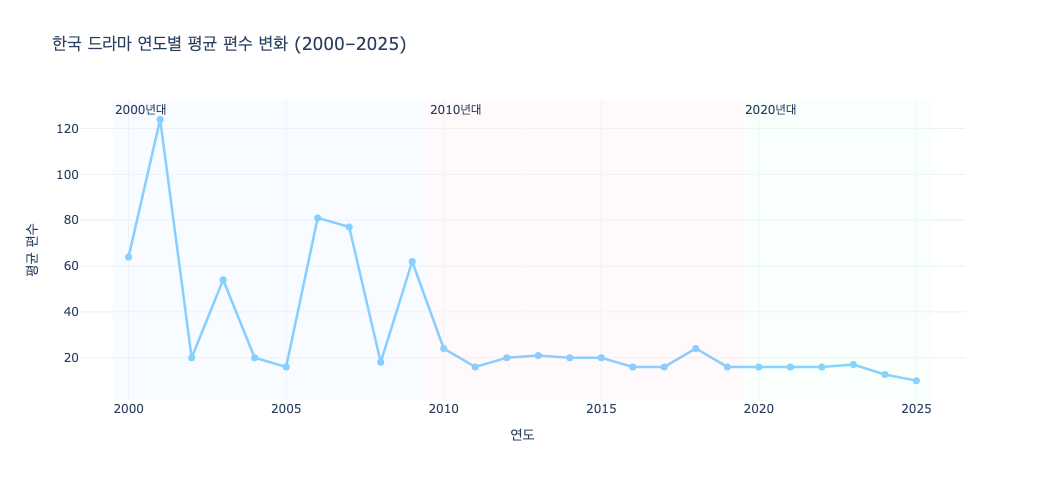

In [11]:
def plot_episodes_trend(yearly: pd.DataFrame) -> None:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=yearly['year'],
        y=yearly['avg_episodes'],
        mode='lines+markers',
        name='평균 편수',
        line=dict(color='#42B6FF', width=2.5),
        marker=dict(size=7),
        text=yearly['avg_episodes'],
        textposition='top center'
    ))

    # 시대 구분 배경
    fig.add_vrect(x0=1999.5, x1=2009.5, fillcolor='#EEF6FF', opacity=0.4, line_width=0, annotation_text='2000년대', annotation_position='top left')
    fig.add_vrect(x0=2009.5, x1=2019.5, fillcolor='#FFF0F8', opacity=0.4, line_width=0, annotation_text='2010년대', annotation_position='top left')
    fig.add_vrect(x0=2019.5, x1=2025.5, fillcolor='#F0FFF4', opacity=0.4, line_width=0, annotation_text='2020년대', annotation_position='top left')

    fig.update_layout(
        title='한국 드라마 연도별 평균 편수 변화 (2000–2025)',
        xaxis_title='연도',
        yaxis_title='평균 편수',
        template='plotly_white',
        height=480
    )
    fig.show()

plot_episodes_trend(yearly)

## 9. 시각화 — 연도별 평균 러닝타임 꺾은선

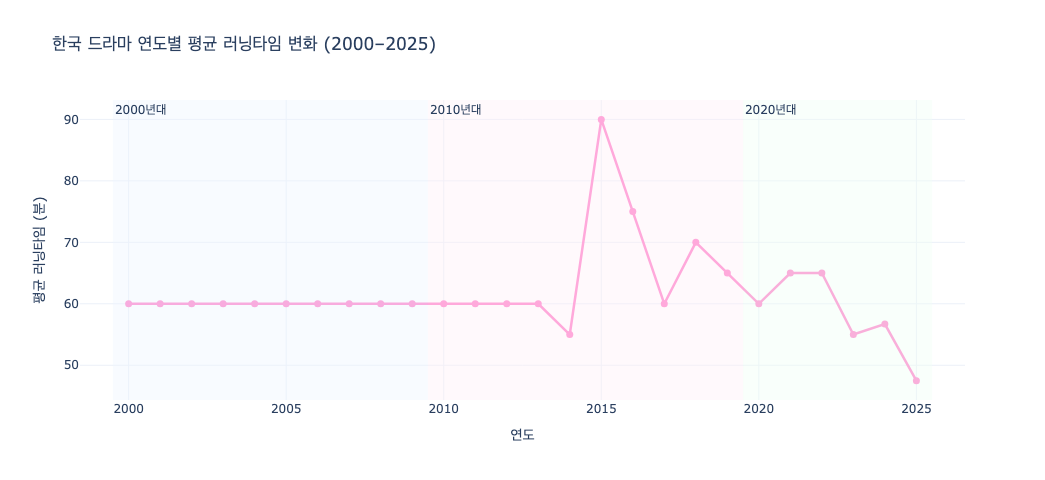

In [12]:
def plot_runtime_trend(yearly: pd.DataFrame) -> None:
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=yearly['year'],
        y=yearly['avg_runtime'],
        mode='lines+markers',
        name='평균 러닝타임(분)',
        line=dict(color='#FF7AC8', width=2.5),
        marker=dict(size=7),
    ))

    fig.add_vrect(x0=1999.5, x1=2009.5, fillcolor='#EEF6FF', opacity=0.4, line_width=0, annotation_text='2000년대', annotation_position='top left')
    fig.add_vrect(x0=2009.5, x1=2019.5, fillcolor='#FFF0F8', opacity=0.4, line_width=0, annotation_text='2010년대', annotation_position='top left')
    fig.add_vrect(x0=2019.5, x1=2025.5, fillcolor='#F0FFF4', opacity=0.4, line_width=0, annotation_text='2020년대', annotation_position='top left')

    fig.update_layout(
        title='한국 드라마 연도별 평균 러닝타임 변화 (2000–2025)',
        xaxis_title='연도',
        yaxis_title='평균 러닝타임 (분)',
        template='plotly_white',
        height=480
    )
    fig.show()

plot_runtime_trend(yearly)

## 10. 시각화 — 편수·러닝타임 2축 통합 차트

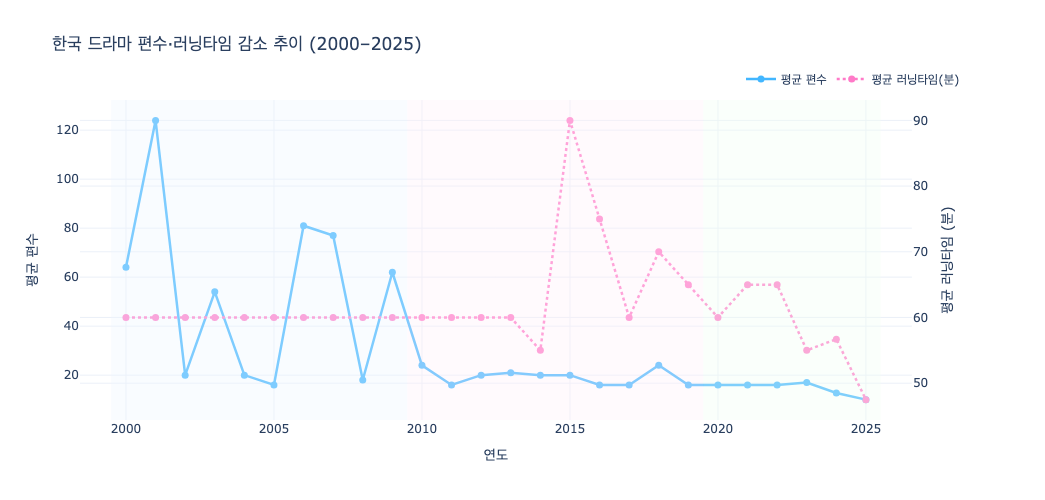

In [13]:
def plot_combined_trend(yearly: pd.DataFrame) -> None:
    fig = make_subplots(specs=[[{'secondary_y': True}]])

    fig.add_trace(go.Scatter(
        x=yearly['year'],
        y=yearly['avg_episodes'],
        name='평균 편수',
        mode='lines+markers',
        line=dict(color='#42B6FF', width=2.5),
        marker=dict(size=7)
    ), secondary_y=False)

    fig.add_trace(go.Scatter(
        x=yearly['year'],
        y=yearly['avg_runtime'],
        name='평균 러닝타임(분)',
        mode='lines+markers',
        line=dict(color='#FF7AC8', width=2.5, dash='dot'),
        marker=dict(size=7)
    ), secondary_y=True)

    fig.add_vrect(x0=1999.5, x1=2009.5, fillcolor='#EEF6FF', opacity=0.35, line_width=0)
    fig.add_vrect(x0=2009.5, x1=2019.5, fillcolor='#FFF0F8', opacity=0.35, line_width=0)
    fig.add_vrect(x0=2019.5, x1=2025.5, fillcolor='#F0FFF4', opacity=0.35, line_width=0)

    fig.update_layout(
        title='한국 드라마 편수·러닝타임 감소 추이 (2000–2025)',
        template='plotly_white',
        height=500,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )
    fig.update_yaxes(title_text='평균 편수', secondary_y=False)
    fig.update_yaxes(title_text='평균 러닝타임 (분)', secondary_y=True)
    fig.update_xaxes(title_text='연도')
    fig.show()

plot_combined_trend(yearly)


## 11. 시각화 — 시대별 평균 비교 바차트

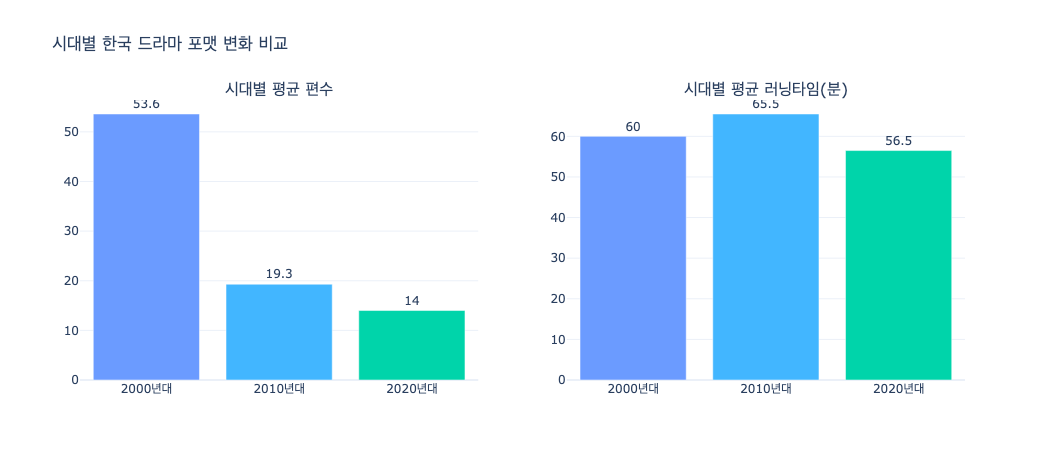


=== 시대별 평균 요약 ===


,era,avg_episodes,avg_runtime
0,2000년대,53.6,60.0
1,2010년대,19.3,65.5
2,2020년대,14.0,56.5


In [14]:
def plot_era_comparison(df: pd.DataFrame) -> None:
    era_summary = (
        df.groupby('era')
        .agg(
            avg_episodes=('episodes',    'mean'),
            avg_runtime =('runtime_min', 'mean')
        )
        .round(1)
        .reset_index()
    )

    era_order  = ['2000년대', '2010년대', '2020년대']
    era_colors = ['#6B9BFF', '#42B6FF', '#00D4AA']

    era_summary = era_summary.set_index('era').reindex(era_order).reset_index()

    fig = make_subplots(rows=1, cols=2, subplot_titles=['시대별 평균 편수', '시대별 평균 러닝타임(분)'])

    fig.add_trace(go.Bar(
        x=era_summary['era'],
        y=era_summary['avg_episodes'],
        marker_color=era_colors,
        text=era_summary['avg_episodes'],
        textposition='outside',
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=era_summary['era'],
        y=era_summary['avg_runtime'],
        marker_color=era_colors,
        text=era_summary['avg_runtime'],
        textposition='outside',
        showlegend=False
    ), row=1, col=2)

    fig.update_layout(
        title='시대별 한국 드라마 포맷 변화 비교',
        template='plotly_white',
        height=460
    )
    fig.show()

    print('\n=== 시대별 평균 요약 ===')
    display(era_summary)

plot_era_comparison(df)

## 12. 저장 결과 확인

In [15]:
def load_summary(engine) -> None:
    try:
        raw_df    = pd.read_sql('SELECT * FROM drama_raw_data ORDER BY year', con=engine)
        yearly_df = pd.read_sql('SELECT * FROM drama_yearly_avg ORDER BY year', con=engine)
        print(f'drama_raw_data    : {len(raw_df)}개')
        print(f'drama_yearly_avg  : {len(yearly_df)}개')
        print('\n=== 연도별 평균 (MySQL) ===')
        display(yearly_df)
    except Exception as e:
        print(f'[ERROR] 조회 실패: {e}')

load_summary(engine)

drama_raw_data    : 30개
drama_yearly_avg  : 26개

=== 연도별 평균 (MySQL) ===


,year,avg_episodes,avg_runtime,drama_count
0,2000,64.0,60.0,1
1,2001,124.0,60.0,1
2,2002,20.0,60.0,1
3,2003,54.0,60.0,1
4,2004,20.0,60.0,1
5,2005,16.0,60.0,1
6,2006,81.0,60.0,1
7,2007,77.0,60.0,1
8,2008,18.0,60.0,1
9,2009,62.0,60.0,1
